# Setup

In [1]:
%load_ext autoreload
%autoreload 2

## Imports

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import hist
import mplhep
import logging
import tpvalidator.workspace as workspace
import tpvalidator.utils as utils
import tpvalidator.analyzers.snn as snn


from rich import print
from tpvalidator.utils import temporary_log_level, pandas_backend

from collections import OrderedDict

## Code

## Data

In [3]:
from tpvalidator.workspace import TriggerAnalysisWorkspace


with temporary_log_level(TriggerAnalysisWorkspace._log, logging.INFO):
    aws = TriggerAnalysisWorkspace('../../e-minus.root', base_folder='taFinder')

# Overview

## Visible energy vs Kinetic energy

- Plot the relationship between $E_{kin}$ and $E_{vis}$
- The trigger operates on visible energy, events with low visible energy will bias efficiency distributions

,tot_visible_energy_rop0,tot_visible_energy_rop1,tot_visible_energy_rop2,tot_visible_energy_rop3,tot_numelectrons_rop0,tot_numelectrons_rop1,tot_numelectrons_rop2,tot_numelectrons_rop3,event,run,...,x,y,z,px,py,pz,p,energy,kinetic_energy,process
event_uid,,,,,,,,,,,,,,,,,,,,,
233328901001,72.045566,72.045644,72.043202,0.0,1.927920e+06,1.927949e+06,1.927921e+06,0.0,1001,2333289,...,220.367813,150.0,450.0,0.061349,0.023318,-0.031060,0.072610,0.072612,0.072101,primary
233328901002,96.706409,96.701183,96.606871,0.0,2.063150e+06,2.063031e+06,2.061413e+06,0.0,1002,2333289,...,-101.257515,150.0,450.0,0.024547,-0.094156,0.006742,0.097536,0.097537,0.097026,primary
233328901003,42.409772,42.411168,42.382898,0.0,9.189194e+05,9.189255e+05,9.184589e+05,0.0,1003,2333289,...,-30.120179,150.0,450.0,-0.038049,0.018062,-0.008793,0.043026,0.043029,0.042518,primary
233328901004,48.989532,48.989502,48.988955,0.0,1.324203e+06,1.324206e+06,1.324191e+06,0.0,1004,2333289,...,290.315777,150.0,450.0,0.031622,0.000983,0.038135,0.049550,0.049553,0.049042,primary
233328901005,36.004213,36.005514,36.006470,0.0,9.693004e+05,9.693018e+05,9.693157e+05,0.0,1005,2333289,...,236.009067,150.0,450.0,-0.022893,-0.023690,-0.015845,0.036556,0.036560,0.036049,primary
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233328900096,87.778397,87.771816,87.710266,0.0,1.904979e+06,1.904778e+06,1.903643e+06,0.0,96,2333289,...,-124.988583,150.0,450.0,0.079641,0.026285,0.028294,0.088511,0.088512,0.088001,primary
233328900097,6.388177,6.391191,6.382882,0.0,1.317252e+05,1.317900e+05,1.316134e+05,0.0,97,2333289,...,-207.562122,150.0,450.0,-0.003559,0.001286,0.005757,0.006889,0.006908,0.006397,primary
233328900098,81.632480,81.629721,81.589900,0.0,1.970101e+06,1.970088e+06,1.969468e+06,0.0,98,2333289,...,126.784283,150.0,450.0,-0.013964,0.081136,-0.000653,0.082332,0.082333,0.081822,primary


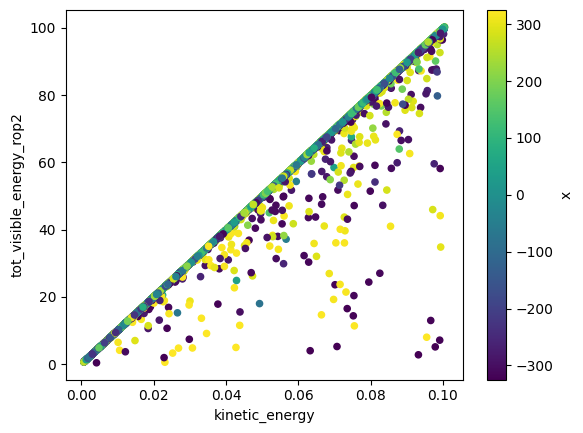

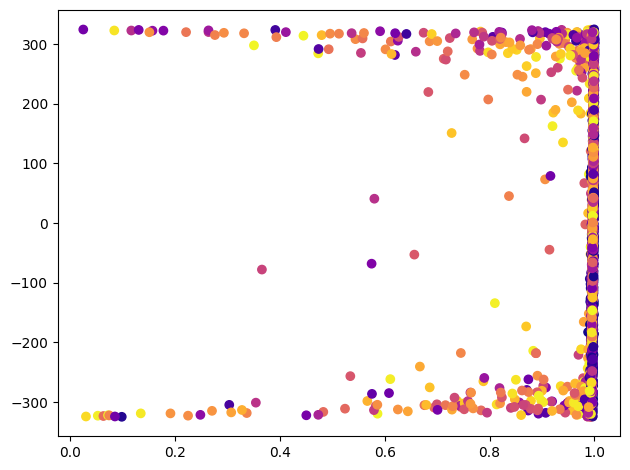

In [4]:
k = aws.event_summary.set_index('event_uid').drop(columns=['event', 'run', 'subrun']).join(aws.mctruths.set_index('event_uid'))
display(k)
k.plot.scatter(x='kinetic_energy', y='tot_visible_energy_rop2', c='x')
ev_sel = ((k['tot_visible_energy_rop2']/(k['kinetic_energy']*1000))> 0.95)

fig,ax=plt.subplots(1,1)

ax.scatter(x=(k['tot_visible_energy_rop2']/(k['kinetic_energy']*1000)), y=k.x, c=k['kinetic_energy'], cmap='plasma')

fig.tight_layout()


# $e^{-}$ Montecarlo inspection

Looking for events with little energy in the active volume

In [5]:
aws.event_summary[['event_uid', 'event', 'run', 'subrun', 'tot_visible_energy_rop2']]
# ke_df = aws.mctruths[['event_uid', 'event', 'run', 'subrun', 'kinetic_energy','x', 'y', 'z']]

ev_sum = aws.event_summary[['event_uid', 'event', 'run', 'subrun', 'tot_visible_energy_rop2']].set_index('event_uid')
ev_sum = ev_sum.join(aws.mctruths[['event_uid', 'kinetic_energy','x', 'y', 'z']].set_index('event_uid'))
ev_sum = ev_sum.join(aws.ta_event_selection[['event_uid', 'accepted', 'num_accept_win', 'num_inspect_win', 'num_inspect_accept_win', 'max_win_sadc', 'max_win_cluster_sadc']].set_index('event_uid'))
ev_sum['kinetic_energy'] *= 1000


# display(ev_sum)

In [6]:
ev_sum.query('kinetic_energy > 25 & kinetic_energy < 30 & accepted == False')

,event,run,subrun,tot_visible_energy_rop2,kinetic_energy,x,y,z,accepted,num_accept_win,num_inspect_win,num_inspect_accept_win,max_win_sadc,max_win_cluster_sadc
event_uid,,,,,,,,,,,,,,
233328902707,2707,2333289,0,29.527799,29.624705,324.168614,150.0,450.0,False,0.0,0.0,0.0,4514.617172,0.0


In [7]:
ev_sum.query('kinetic_energy > 0.05 & accepted == False')

,event,run,subrun,tot_visible_energy_rop2,kinetic_energy,x,y,z,accepted,num_accept_win,num_inspect_win,num_inspect_accept_win,max_win_sadc,max_win_cluster_sadc
event_uid,,,,,,,,,,,,,,
233328901028,1028,2333289,0,1.739123,1.744394,-209.563780,150.0,450.0,False,0.0,0.0,0.0,10300.764677,0.0
233328901042,1042,2333289,0,3.730640,3.736002,182.086301,150.0,450.0,False,0.0,0.0,0.0,14773.563001,0.0
233328901092,1092,2333289,0,1.191561,1.193523,-107.978654,150.0,450.0,False,0.0,0.0,0.0,8930.271208,0.0
233328900108,108,2333289,0,3.898825,3.908010,140.651610,150.0,450.0,False,0.0,0.0,0.0,14090.735669,0.0
233328901115,1115,2333289,0,2.240081,2.247435,-283.080557,150.0,450.0,False,0.0,0.0,0.0,7282.023914,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233328900911,911,2333289,0,2.189808,2.193666,-46.691886,150.0,450.0,False,0.0,0.0,0.0,13635.178846,0.0
233328900943,943,2333289,0,9.395144,9.450448,-244.484568,150.0,450.0,False,0.0,0.0,0.0,12683.312368,0.0
233328900957,957,2333289,0,2.464869,2.465204,147.086322,150.0,450.0,False,0.0,0.0,0.0,11812.279231,0.0


In [8]:
ev_sum.query('x < -320 | x > 320')

,event,run,subrun,tot_visible_energy_rop2,kinetic_energy,x,y,z,accepted,num_accept_win,num_inspect_win,num_inspect_accept_win,max_win_sadc,max_win_cluster_sadc
event_uid,,,,,,,,,,,,,,
233328901041,1041,2333289,0,39.370942,41.998619,324.162570,150.0,450.0,True,0.0,2.0,1.0,25164.195916,17367.0
233328901054,1054,2333289,0,11.544981,43.790300,320.471019,150.0,450.0,NaN,NaN,NaN,NaN,NaN,NaN
233328901187,1187,2333289,0,14.667924,66.411341,320.313373,150.0,450.0,NaN,NaN,NaN,NaN,NaN,NaN
233328901385,1385,2333289,0,53.550455,53.585378,320.151621,150.0,450.0,True,1.0,0.0,0.0,127586.701642,0.0
233328901389,1389,2333289,0,86.558494,87.082123,324.114218,150.0,450.0,True,1.0,1.0,1.0,132447.211615,19595.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233328900478,478,2333289,0,8.960733,8.997316,-320.069563,150.0,450.0,True,0.0,1.0,1.0,29884.103345,18685.0
233328904843,4843,2333289,0,72.003037,74.563667,-321.449280,150.0,450.0,True,1.0,1.0,1.0,120179.645432,27589.0
233328904896,4896,2333289,0,31.045008,35.248752,323.643297,150.0,450.0,False,0.0,1.0,0.0,15970.124776,0.0


In [9]:
ev_sum.query('tot_visible_energy_rop2/kinetic_energy < 0.20')

,event,run,subrun,tot_visible_energy_rop2,kinetic_energy,x,y,z,accepted,num_accept_win,num_inspect_win,num_inspect_accept_win,max_win_sadc,max_win_cluster_sadc
event_uid,,,,,,,,,,,,,,
233328901660,1660,2333289,0,8.012967,95.530288,323.069900,150.0,450.0,NaN,NaN,NaN,NaN,NaN,NaN
233328901977,1977,2333289,0,5.135822,97.902783,-322.948518,150.0,450.0,False,0.0,0.0,0.0,10059.083273,0.0
233328902082,2082,2333289,0,4.975159,42.750204,323.029763,150.0,450.0,NaN,NaN,NaN,NaN,NaN,NaN
233328902266,2266,2333289,0,4.812302,30.706593,322.739694,150.0,450.0,NaN,NaN,NaN,NaN,NaN,NaN
233328902566,2566,2333289,0,3.995770,63.289768,-323.505604,150.0,450.0,False,0.0,0.0,0.0,7416.516136,0.0
233328902819,2819,2333289,0,7.139722,99.140856,-322.233593,150.0,450.0,True,0.0,1.0,1.0,20814.575639,12119.0
233328903014,3014,2333289,0,2.784271,93.245860,-324.280348,150.0,450.0,NaN,NaN,NaN,NaN,NaN,NaN
233328903045,3045,2333289,0,4.769950,26.853903,322.831979,150.0,450.0,NaN,NaN,NaN,NaN,NaN,NaN
233328903093,3093,2333289,0,0.570914,23.085250,324.710861,150.0,450.0,NaN,NaN,NaN,NaN,NaN,NaN


# First look at efficiencies

In [10]:
ev_sum = ev_sum.query("kinetic_energy < 50")

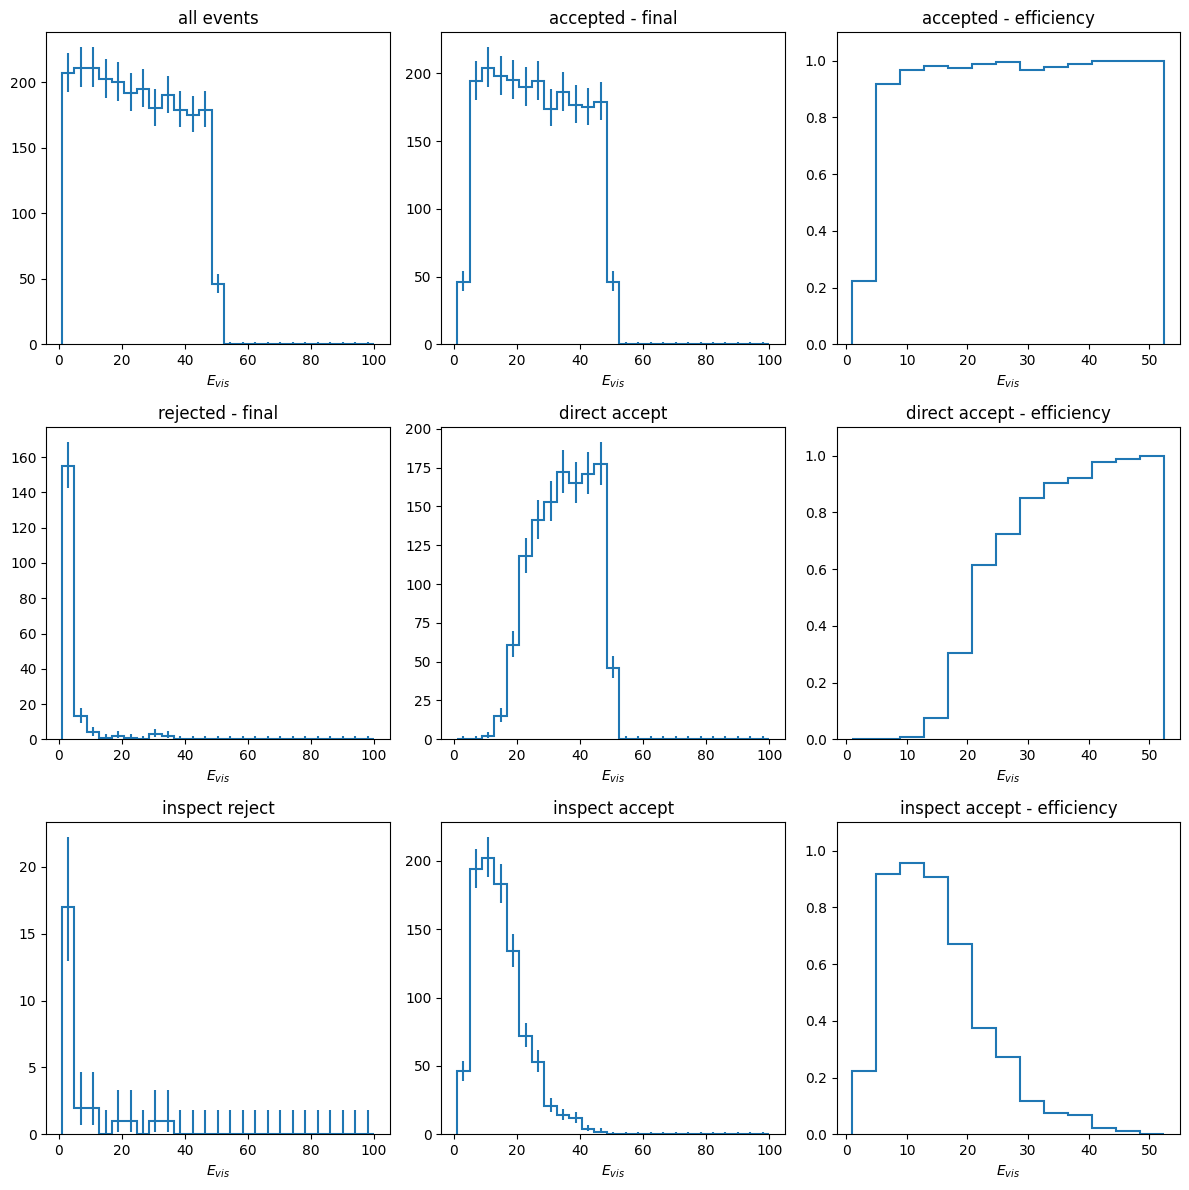

In [11]:
energy_var = 'kinetic_energy'
label='$E_{kin}$'

energy_var = 'tot_visible_energy_rop2'
label='$E_{vis}$'


ke_ax = hist.axis.Regular(25, 1, 100, name=label, flow=False)

h_ke = hist.Hist(ke_ax, storage=hist.storage.Double())
h_ke.fill(ev_sum[energy_var])

h_ke_acc = hist.Hist(ke_ax, storage=hist.storage.Double())
h_ke_acc.fill(ev_sum.query('accepted == True')[energy_var])

h_ke_rej = hist.Hist(ke_ax, storage=hist.storage.Double())
h_ke_rej.fill(ev_sum.query('accepted == False')[energy_var])

h_ke_dir_acc = hist.Hist(ke_ax, storage=hist.storage.Double())
h_ke_dir_acc.fill(ev_sum.query('num_accept_win > 0')[energy_var])

h_ke_insp_acc = hist.Hist(ke_ax, storage=hist.storage.Double())
h_ke_insp_acc.fill(ev_sum.query('num_accept_win == 0 & num_inspect_accept_win > 0')[energy_var])

h_ke_insp_rej = hist.Hist(ke_ax, storage=hist.storage.Double())
h_ke_insp_rej.fill(ev_sum.query('num_accept_win == 0 & num_inspect_win > 0 & max_win_cluster_sadc < 7500')[energy_var])

r = (h_ke_acc/h_ke)


fig,axes = plt.subplots(3,3, figsize=(12,12))
ax=axes[0][0]
mplhep.histplot(h_ke, ax=ax)
ax.set_title('all events')

ax=axes[0][1]
mplhep.histplot(h_ke_acc, ax=ax)
ax.set_title('accepted - final')

ax=axes[0][2]
mplhep.histplot(r, ax=ax)
ax.set_ylim(0,1.1)
ax.set_title('accepted - efficiency')


ax=axes[1,0]
mplhep.histplot(h_ke_rej, ax=ax)
ax.set_title('rejected - final')

ax=axes[1,1]
mplhep.histplot(h_ke_dir_acc, ax=ax)
ax.set_title('direct accept')
ax=axes[1,2]
mplhep.histplot(h_ke_dir_acc/h_ke, ax=ax)
ax.set_ylim(0,1.1)
ax.set_title('direct accept - efficiency')

ax=axes[2,0]
mplhep.histplot(h_ke_insp_rej, ax=ax)
ax.set_title('inspect reject')

ax=axes[2,1]
mplhep.histplot(h_ke_insp_acc, ax=ax)
ax.set_title('inspect accept')


ax=axes[2,2]
mplhep.histplot(h_ke_insp_acc/h_ke, ax=ax)
ax.set_title('inspect accept - efficiency')
ax.set_ylim(0,1.1)

fig.tight_layout()



In [12]:
ev_sum.query('accepted == False & tot_visible_energy_rop2 > 30')

,event,run,subrun,tot_visible_energy_rop2,kinetic_energy,x,y,z,accepted,num_accept_win,num_inspect_win,num_inspect_accept_win,max_win_sadc,max_win_cluster_sadc
event_uid,,,,,,,,,,,,,,
233328901452,1452,2333289,0,30.801208,31.228214,318.361229,150.0,450.0,False,0.0,0.0,0.0,10817.189627,0.0
233328900201,201,2333289,0,33.589984,33.818977,319.143024,150.0,450.0,False,0.0,1.0,0.0,21915.688365,0.0
233328904042,4042,2333289,0,34.671410,38.850184,322.150567,150.0,450.0,False,0.0,0.0,0.0,2451.542250,0.0
233328904896,4896,2333289,0,31.045008,35.248752,323.643297,150.0,450.0,False,0.0,1.0,0.0,15970.124776,0.0


## Event inspection

         event_uid  event      run  subrun  block_id  truth_track_id  pdg  \
2596  233328903377   3377  2333289       0         0              -1   11   

     generator_name  status_code          x      y      z      px        py  \
2596      generator            1 -155.45187  150.0  450.0 -0.0297  0.030331   

            pz         p    energy  kinetic_energy  process  
2596 -0.031284  0.052733  0.052735        0.052224  primary  


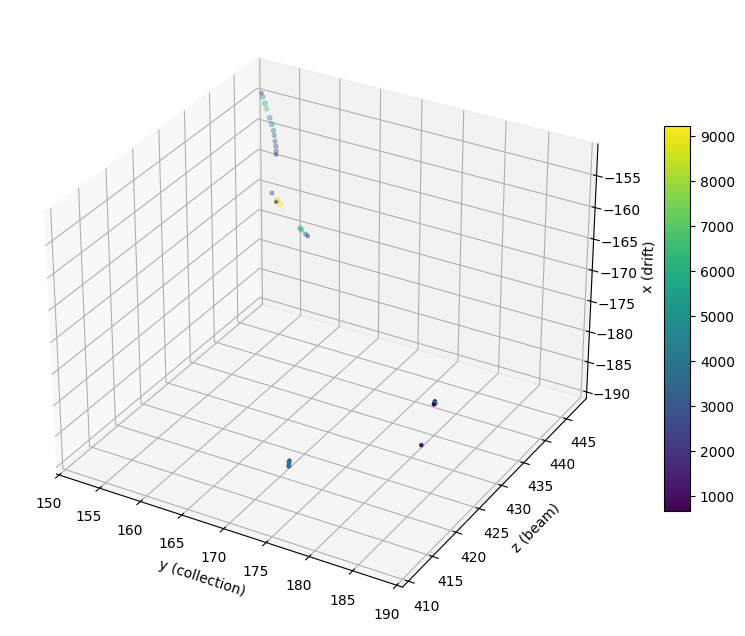

In [13]:
from tpvalidator.viz.display import TriggerPrimitivesEventViewer

tpv = TriggerPrimitivesEventViewer(aws, labels={'tps':'tps_with_cluster_flags'})

ev_uid = 233328903377
# ev_uid = 233328903121
# ev_uid = 233328903478
# ev_uid = 233328902221
# ev_uid = 233339201244
# ev_uid = 233339200682
fig = tpv.draw_tps_point_of_origin(ev_uid=ev_uid, figsize=(8,8))
# display(fig1)
# fig = tpv.draw_tps(ev_uid=ev_uid, figsize=(8,8))




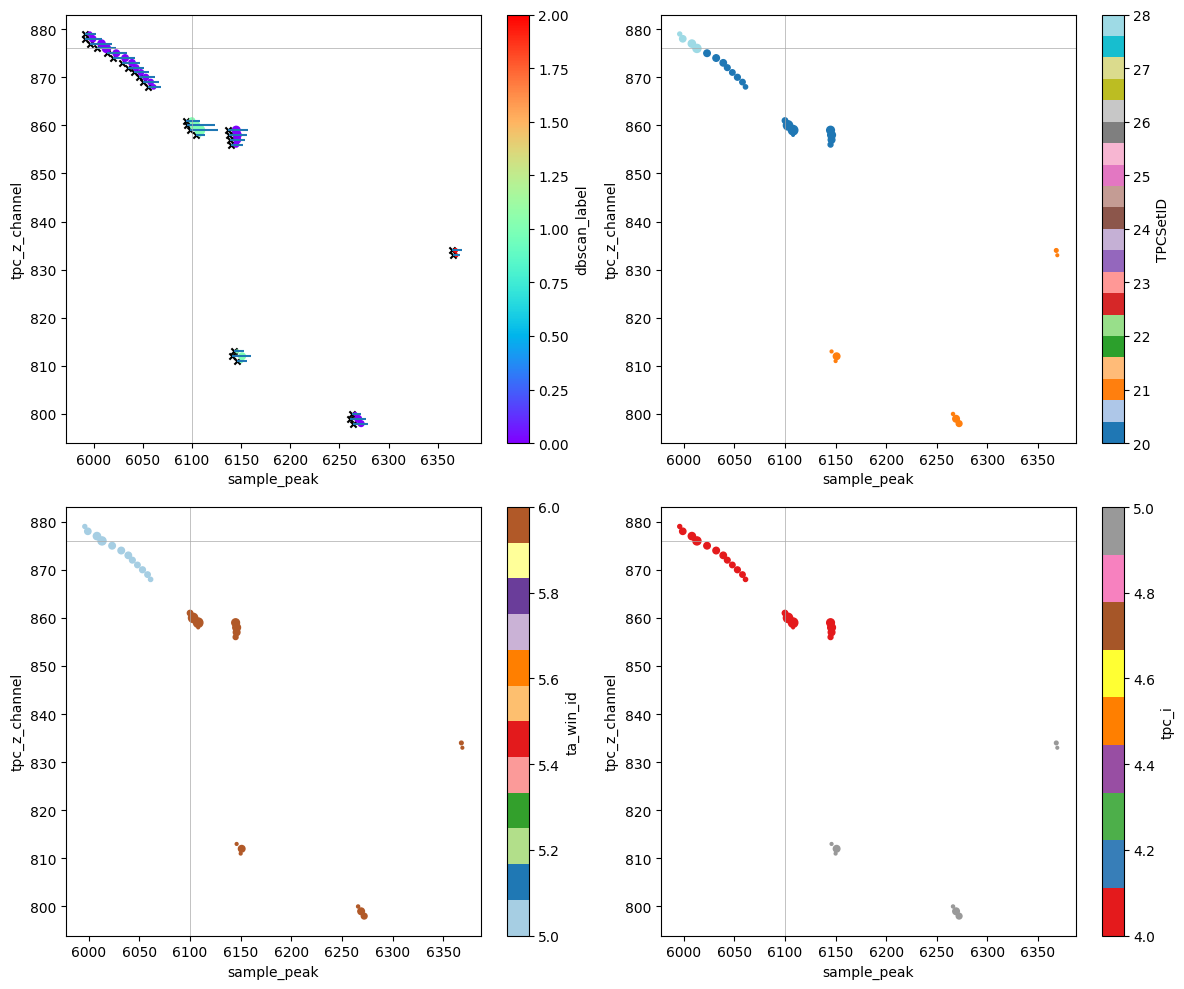

In [ ]:
import tpvalidator.detector_geometry as geo

def decorate_tpc_coords(tps, detgeo):

    tps['tpc_view_channel'] = tps.channel.apply(lambda c: detgeo.tpc_view_channel(c)[1]).astype('int16')
    tps[['tpc_i', 'tpc_k']] = pd.DataFrame(tps.TPCSetID.apply(detgeo.tpc_id_to_grid).tolist(), index=tps.index).rename({0:'tpc_i', 1:'tpc_k'}, axis=1)
    tps['tpc_z_channel'] = (tps['tpc_view_channel']+detgeo.tpc_view_2_num_chans_sim*tps['tpc_k']).where(tps['readout_view'] == 2, -1)


def draw_tawin_boundaries(ax):

    ymin, ymax = ax.get_ylim()
    for k in range(0, geo.FDVDGeometry_1x8x6.tpc_geo[2]*geo.FDVDGeometry_1x8x6.tpc_view_2_num_chans_sim, geo.FDVDGeometry_1x8x6.tpc_view_2_num_chans_sim):
        if k < ymin or k > ymax:
            continue
        ax.axhline(k, c='darkgrey', lw=0.5)

    xmin, xmax = ax.get_xlim()
    for t in range(100, 8500, 1000):
        # print(t)
        if t < xmin or t > xmax:
            continue
        ax.axvline(t, c='darkgrey', lw=0.5)


decorate_tpc_coords(aws.tps_with_cluster_flags, geo.FDVDGeometry_1x8x6)
tps_coll_ev = aws.tps_with_cluster_flags.query(f"event_uid=={ev_uid}")


fig, axes = plt.subplots(2,2, figsize=(12, 10))


ax = axes[0][0]

tps_coll_ev.plot.scatter(x='sample_start', y='tpc_z_channel', s=20, marker='x', c='k', ax=ax)
tps_coll_ev.plot.scatter(x='sample_peak', y='tpc_z_channel', s=tps_coll_ev['adc_integral']/200, c='dbscan_label', cmap='rainbow', ax=ax)

ax.hlines(y=tps_coll_ev.tpc_z_channel.values, xmin=tps_coll_ev.sample_start, xmax=(tps_coll_ev.sample_start+tps_coll_ev.samples_over_threshold))

draw_tawin_boundaries(ax)


ax = axes[0][1]

tps_coll_ev.plot.scatter(x='sample_peak', y='tpc_z_channel', s=tps_coll_ev['adc_integral']/200, c='TPCSetID', cmap='tab20', ax=ax)

draw_tawin_boundaries(ax)


ax = axes[1][0]

tps_coll_ev.plot.scatter(x='sample_peak', y='tpc_z_channel', s=tps_coll_ev['adc_integral']/200, c='ta_win_id', cmap='Paired', ax=ax)

draw_tawin_boundaries(ax)

ax = axes[1][1]

tps_coll_ev.plot.scatter(x='sample_peak', y='tpc_z_channel', s=tps_coll_ev['adc_integral']/200, c='tpc_i', cmap='Set1', ax=ax)

draw_tawin_boundaries(ax)

fig.tight_layout()







# pd.set_option('display.max_columns', None)  # or 1000
# pd.set_option('display.max_rows', None)  # or 1000
# pd.set_option('display.max_colwidth', None)  # or 199

# print("[yellow]High ADCI TPs[/yellow]")
# display(tps_coll_ev.query('adc_integral > 8000'))


# print("[yellow]Clustered TPs TPs[/yellow]")
# display(tps_coll_ev.query('dbscan_label != -1'))
# xxx = tps_coll_ev.query('adc_integral > 8000').copy()

# from tpvalidator.algo.tafinder.trigger_algs_numba import add_dbscan_variables
# display(add_dbscan_variables(xxx))


# ax = axes[1]
# xxx.plot.scatter(x='dbs_t', y='dbs_z', s=xxx['adc_integral']/200, c='adc_integral', cmap='rainbow', ax=ax)
# ax.set_xlim(15550, 15650)
# ax.set_ylim(9240, 9250)
# ax.grid()
# fig.tight_layout()


In [16]:
for r in aws.ta_clusters.query(f'event_uid == {ev_uid}').iterrows():
    ax.text(x=r[1]['sample_peak_mean'], y=840, s=f"{r[1]['TPCSetID']}")
    # print(r[1]['TPCSetID'])
    # print(r)

In [17]:
display(aws.ta_win_cluster_stats.query('event_uid == 233328903377'))
display(aws.mctruths.query('event_uid == 233328901003'))

,event_uid,event,run,subrun,TPCSetID,ta_win_id,n_tps,sadc,channel_std,sample_peak_std,bkg_sadc,sadc_window_thres_lo,sadc_window_thres_hi,n_clusters,mean_cluster_sadc,total_cluster_sadc,max_cluster_sadc
5473,233328903377,3377,2333289,0,20,6,8,45277.864829,1.603567,21.937818,3828.864829,True,False,2.0,20724.5,41449.0,21889.0
5474,233328903377,3377,2333289,0,20,5,8,33020.437848,2.449490,13.037720,4909.437848,True,False,1.0,28111.0,28111.0,28111.0
5475,233328903377,3377,2333289,0,21,6,8,23293.275486,14.312831,92.422071,6085.275486,True,False,3.0,5736.0,17208.0,8979.0
5476,233328903377,3377,2333289,0,28,5,4,19769.349111,1.290994,7.874008,1770.349111,True,False,1.0,17999.0,17999.0,17999.0


,event_uid,event,run,subrun,block_id,truth_track_id,pdg,generator_name,status_code,x,y,z,px,py,pz,p,energy,kinetic_energy,process
2,233328901003,1003,2333289,0,0,-1,11,generator,1,-30.120179,150.0,450.0,-0.038049,0.018062,-0.008793,0.043026,0.043029,0.042518,primary


In [18]:
geo.FDVDGeometry_1x8x6.tpc_id_to_grid(10)

(2, 1)

In [19]:
geo.FDVDGeometry_1x8x6.tpc_view_channel(22500)

(0, 36)

In [49]:
import tpvalidator.datasets.miniprod as miniprod

datasets = miniprod.load_tp_presel_datasets(['radbkg'])

Key 'triggerAna/mctruths' not found in file.
Key 'triggerAna/mcneutrinos' not found in file.
Key 'triggerAna/mcparticles' not found in file.
Key 'triggerAna/simides' not found in file.


Dataset 'radbkg': 9930 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x6ref'},
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 45,
            'threshold_tpg_plane1': 45,
            'threshold_tpg_plane2': 45,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

In [50]:
tps_coll_ev

,event_uid,event,run,subrun,version,flag,detid,channel,samples_over_threshold,time_start,...,time_peak,sample_start,sample_peak,bt_is_signal,ta_win_id,dbscan_label,tpc_view_channel,tpc_i,tpc_k,tpc_z_channel
56608,233328903377,3377,2333289,0,2,0,3,18124,12,196480,...,196640,6140,6145,1,6,0,272,4,2,856
56609,233328903377,3377,2333289,0,2,0,3,18125,15,196448,...,196672,6139,6146,1,6,0,273,4,2,857
56610,233328903377,3377,2333289,0,2,0,3,18126,9,195328,...,195456,6104,6108,1,6,1,274,4,2,858
56611,233328903377,3377,2333289,0,2,0,3,18126,18,196416,...,196672,6138,6146,1,6,0,274,4,2,858
56612,233328903377,3377,2333289,0,2,0,3,18127,28,195136,...,195456,6098,6108,1,6,1,275,4,2,859
56613,233328903377,3377,2333289,0,2,0,3,18127,20,196384,...,196640,6137,6145,1,6,0,275,4,2,859
56614,233328903377,3377,2333289,0,2,0,3,18128,28,195040,...,195296,6095,6103,1,6,1,276,4,2,860
56615,233328903377,3377,2333289,0,2,0,3,18129,14,195008,...,195200,6094,6100,1,6,1,277,4,2,861
56616,233328903377,3377,2333289,0,2,0,3,18136,13,193760,...,193952,6055,6061,1,5,0,284,4,2,868
56617,233328903377,3377,2333289,0,2,0,3,18137,16,193600,...,193856,6050,6058,1,5,0,285,4,2,869
